In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet("../data/churn_frame.parquet")
TARGET = "churned_next_cycle"
EXCLUDE = [TARGET, "cycle_start", "cycle_end", "customer_id"]

print(f"Dataset: {df.shape[0]} rows x {df.shape[1]} cols")
print(f"Churn rate: {df[TARGET].mean():.2%}")
df.head(3)

Dataset: 8000 rows x 25 cols
Churn rate: 12.05%


,customer_id,cycle_start,cycle_end,billing_amount,last_payment_days_ago,plan_tier,tenure_months,monthly_usage_hours,active_days,login_count,...,promotions_redeemed,email_opens,email_clicks,last_campaign_days_ago,nps_score,region,is_autopay,is_discounted,has_family_bundle,churned_next_cycle
0,CUST_00000,2023-12-04,2024-01-03,613.43,21.1,standard,11.3,13.91,22.0,12.0,...,1.0,1.0,0.0,36.6,9.0,north,True,False,True,0
1,CUST_00001,2024-06-05,2024-07-05,597.42,7.4,standard,72.2,18.79,19.0,8.0,...,0.0,6.0,2.0,0.2,8.0,east,False,False,False,0
2,CUST_00002,2023-01-01,2023-01-31,332.41,10.9,basic,31.6,33.39,19.0,8.0,...,2.0,4.0,1.0,12.4,5.0,west,False,True,False,0


In [2]:
counts = df[TARGET].value_counts()
pcts   = df[TARGET].value_counts(normalize=True)

print("=== Class Distribution ===")
for cls, cnt in counts.items():
    bar = "█" * int(pcts[cls] * 40)
    label = "Churned" if cls == 1 else "Retained"
    print(f"  {label} [{cls}]: {cnt:,} ({pcts[cls]:.1%})  {bar}")

print("\n⚠️  Imbalance ratio:", round(counts[0]/counts[1], 1), ":1")
print("Strategy: use scale_pos_weight in XGBoost, class_weight='balanced' for sklearn models")

=== Class Distribution ===
  Retained [0]: 7,036 (87.9%)  ███████████████████████████████████
  Churned [1]: 964 (12.0%)  ████

⚠️  Imbalance ratio: 7.3 :1
Strategy: use scale_pos_weight in XGBoost, class_weight='balanced' for sklearn models


In [3]:
# Features available at prediction time (end of cycle T)
SAFE_FEATURES = [c for c in df.columns if c not in EXCLUDE]

# Potential leakage candidates — comment on each
LEAKAGE_RISK = {
    "cycle_start": "DATE — used for time-split only, not a feature",
    "cycle_end":   "DATE — prediction is made AT this point, exclude",
    "customer_id": "IDENTIFIER — not predictive",
}

print("=== Leakage Audit ===")
for col, reason in LEAKAGE_RISK.items():
    print(f"  ✗ EXCLUDED  {col:30s} | {reason}")

print(f"\n✅ {len(SAFE_FEATURES)} safe features will be used in modeling:")
for f in SAFE_FEATURES:
    print(f"   • {f}")

=== Leakage Audit ===
  ✗ EXCLUDED  cycle_start                    | DATE — used for time-split only, not a feature
  ✗ EXCLUDED  cycle_end                      | DATE — prediction is made AT this point, exclude
  ✗ EXCLUDED  customer_id                    | IDENTIFIER — not predictive

✅ 21 safe features will be used in modeling:
   • billing_amount
   • last_payment_days_ago
   • plan_tier
   • tenure_months
   • monthly_usage_hours
   • active_days
   • login_count
   • avg_session_min
   • device_count
   • add_on_count
   • support_tickets
   • sla_breaches
   • promotions_redeemed
   • email_opens
   • email_clicks
   • last_campaign_days_ago
   • nps_score
   • region
   • is_autopay
   • is_discounted
   • has_family_bundle


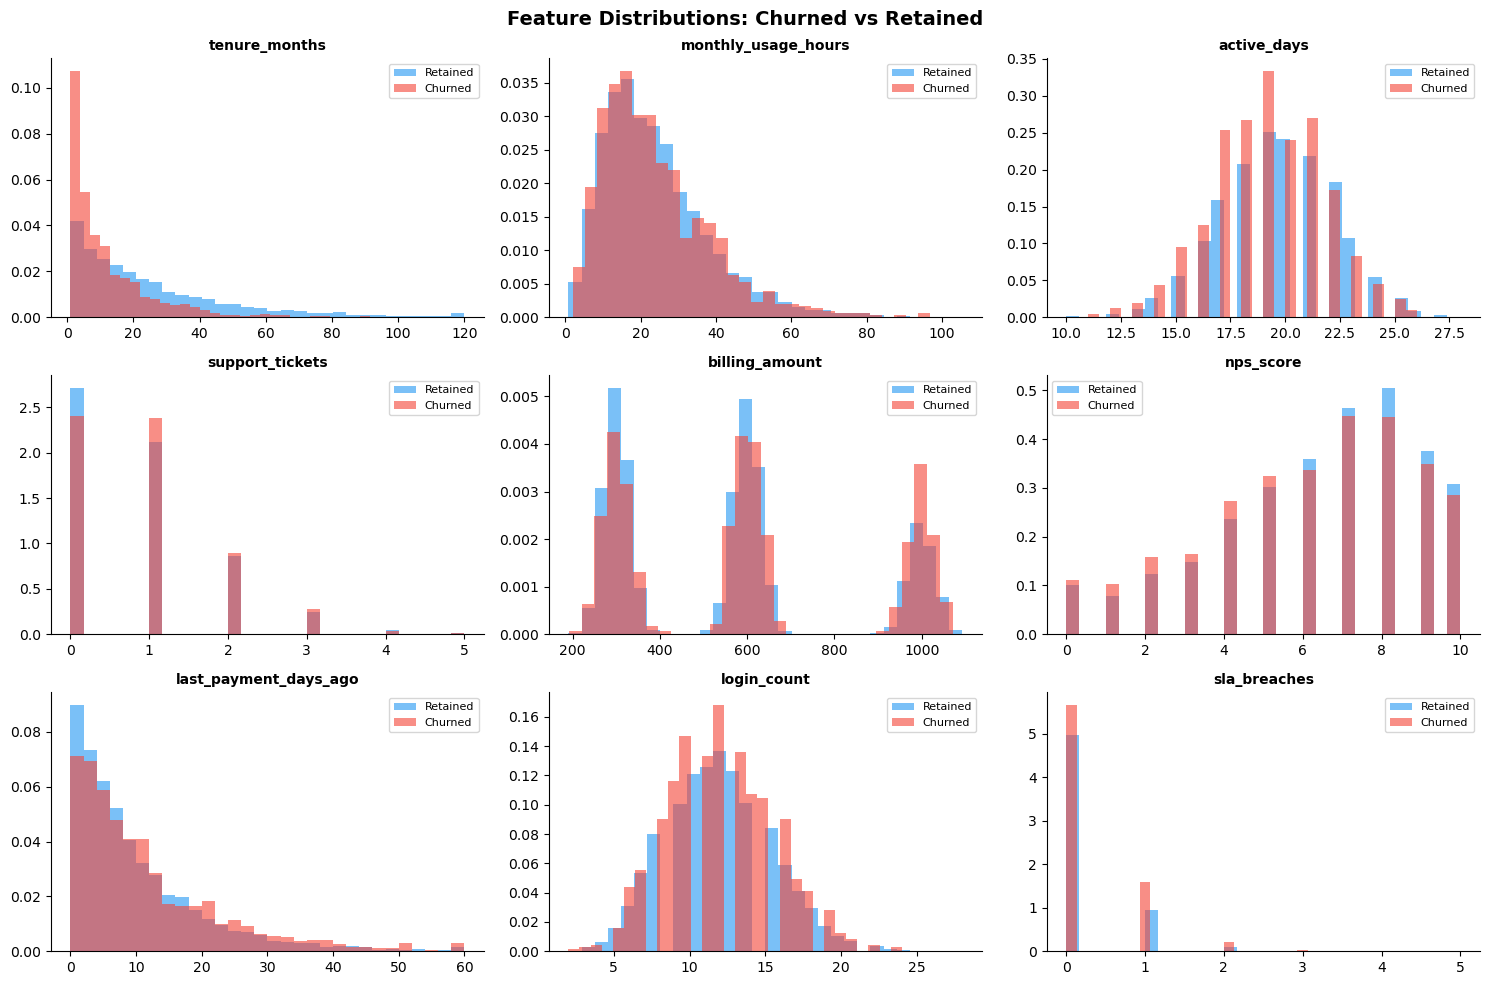

Saved → ../data/eda_distributions.png


In [4]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle("Feature Distributions: Churned vs Retained", fontsize=14, fontweight='bold')
axes = axes.flatten()

numeric_feats = [
    "tenure_months", "monthly_usage_hours", "active_days",
    "support_tickets", "billing_amount", "nps_score",
    "last_payment_days_ago", "login_count", "sla_breaches"
]

colors = {0: "#2196F3", 1: "#F44336"}
labels = {0: "Retained", 1: "Churned"}

for ax, feat in zip(axes, numeric_feats):
    for cls in [0, 1]:
        subset = df[df[TARGET] == cls][feat].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=colors[cls],
                label=labels[cls], density=True, edgecolor='none')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel("")
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig("../data/eda_distributions.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved → ../data/eda_distributions.png")

In [5]:
# Missing values
miss = df[SAFE_FEATURES].isnull().mean().sort_values(ascending=False)
print("=== Missing Values (top 10) ===")
print(miss.head(10).to_string())
print(f"\n✅ Max missing: {miss.max():.1%}")

# Correlation with target
print("\n=== Correlation with Churn Target (top 10) ===")
corr = df[SAFE_FEATURES + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET)
corr_sorted = corr.abs().sort_values(ascending=False).head(10)
for feat, val in corr_sorted.items():
    direction = "▲" if corr[feat] > 0 else "▼"
    print(f"  {direction} {feat:35s}: {corr[feat]:+.3f}")

=== Missing Values (top 10) ===
billing_amount            0.0
sla_breaches              0.0
is_discounted             0.0
is_autopay                0.0
region                    0.0
nps_score                 0.0
last_campaign_days_ago    0.0
email_clicks              0.0
email_opens               0.0
promotions_redeemed       0.0

✅ Max missing: 0.0%

=== Correlation with Churn Target (top 10) ===
  ▼ tenure_months                      : -0.189
  ▼ is_autopay                         : -0.104
  ▼ is_discounted                      : -0.068
  ▲ sla_breaches                       : +0.066
  ▼ active_days                        : -0.060
  ▲ billing_amount                     : +0.056
  ▼ has_family_bundle                  : -0.054
  ▲ last_payment_days_ago              : +0.051
  ▼ nps_score                          : -0.033
  ▲ support_tickets                    : +0.024


In [6]:
df["cycle_start_dt"] = pd.to_datetime(df["cycle_start"])

# Sort by time, use last 20% cycles as validation
df_sorted = df.sort_values("cycle_start_dt").reset_index(drop=True)
split_idx  = int(len(df_sorted) * 0.80)
split_date = df_sorted.iloc[split_idx]["cycle_start_dt"]

train_df = df_sorted.iloc[:split_idx]
val_df   = df_sorted.iloc[split_idx:]

print("=== Time-Based Split ===")
print(f"  Train: {len(train_df):,} rows | {train_df['cycle_start_dt'].min().date()} → {train_df['cycle_start_dt'].max().date()}")
print(f"  Val:   {len(val_df):,} rows  | {val_df['cycle_start_dt'].min().date()} → {val_df['cycle_start_dt'].max().date()}")
print(f"  Split date: {split_date.date()}")
print(f"\n  Train churn rate: {train_df[TARGET].mean():.2%}")
print(f"  Val   churn rate: {val_df[TARGET].mean():.2%}")
print("\n✅ No future data leaks into training set")

=== Time-Based Split ===
  Train: 6,400 rows | 2023-01-01 → 2024-07-30
  Val:   1,600 rows  | 2024-07-30 → 2024-12-20
  Split date: 2024-07-30

  Train churn rate: 12.16%
  Val   churn rate: 11.62%

✅ No future data leaks into training set
